# Real Estate Price Prediction — Capstone Final Deliverable
### King County House Sales Regression Analysis

**Student Name:** [Your Full Name]
**Topic:** Real Estate Price Prediction (Regression)
**Cohort:** DSB [Cohort Ref.]
**Data Source:** [King County House Sales — Kaggle](https://www.kaggle.com/datasets/harlfoxem/housesalesprediction)

---

## Introduction
This project analyzes ~21,600 residential property sales in King County, Washington (which includes
Seattle), recorded between May 2014 and May 2015. Each record describes one house sale: its physical
characteristics (size, bedrooms, bathrooms, condition, construction grade), its location
(zip code, latitude/longitude), and the sale `price`.

The capstone builds on the work from Lightning Talk #1 (topic selection) and Lightning Talk #2
(cleaning, EDA, and modeling plan) by completing the full modeling phase: three model families are
built, each is improved beyond its basic version, and the best-performing model is selected and
justified.

## Problem Statement + Aim
House prices fluctuate significantly, and buyers and sellers may face substantially different
property prices depending on factors such as living area, number of bedrooms, bathrooms, location,
house condition, grade, waterfront view, and year built. These variations make it hard for buyers,
sellers, and agents to judge whether a listed price is fair.

**Aim:** build a regression model that predicts a house's sale `price` from its physical and
locational attributes, so the estimate can serve as a fair-value benchmark for buyers, sellers, and
agents.

**Success metrics:** minimize **MAE** and **RMSE** on held-out data while maximizing **R²**.

## Objectives
- What features influence `price` the most?
- Does feature engineering (house age, renovation flag, studio flag) improve model performance?
- How do different model families compare — linear, regularized linear, and tree ensembles?
- Does predicting `log(price)` instead of raw `price` help, given the skewed target?
- Which model, after tuning/improvement, gives the best generalization on unseen data, and why?

# Data Inspection
## Data Dictionary
| Column | Type | Description |
|---|---|---|
| id | int | Unique house identifier |
| date | object | Date the house was sold |
| price | float | **Target.** Sale price |
| bedrooms | int | Number of bedrooms |
| bathrooms | float | Number of bathrooms |
| sqft_living | int | Living space square footage |
| sqft_lot | int | Lot square footage |
| floors | float | Number of floors |
| waterfront | int | 1 if property has a waterfront view |
| view | int | Quality of view (0–4 scale) |
| condition | int | Overall condition rating (1–5) |
| grade | int | Construction/design quality grade |
| sqft_above | int | Square footage above ground |
| sqft_basement | int | Square footage of basement |
| yr_built | int | Year house was built |
| yr_renovated | int | Year renovated (0 if never) |
| zipcode | int | Zip code |
| lat / long | float | Latitude / longitude |
| sqft_living15 | int | Living space of nearest 15 neighbors (avg) |
| sqft_lot15 | int | Lot size of nearest 15 neighbors (avg) |

In [2]:
# Core imports used throughout the notebook
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import f_regression, chi2
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## Data Overview
Source: King County House Sales dataset (CSV). Load and inspect shape, types, and summary stats.

In [3]:
df = pd.read_csv('./Data/kc_house_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,"221,900.00",3,1.00,1180,5650,1.00,0,0,...,7,1180,0,1955,0,98178,47.51,-122.26,1340,5650
1,6414100192,20141209T000000,"538,000.00",3,2.25,2570,7242,2.00,0,0,...,7,2170,400,1951,1991,98125,47.72,-122.32,1690,7639
2,5631500400,20150225T000000,"180,000.00",2,1.00,770,10000,1.00,0,0,...,6,770,0,1933,0,98028,47.74,-122.23,2720,8062
3,2487200875,20141209T000000,"604,000.00",4,3.00,1960,5000,1.00,0,0,...,7,1050,910,1965,0,98136,47.52,-122.39,1360,5000
4,1954400510,20150218T000000,"510,000.00",3,2.00,1680,8080,1.00,0,0,...,8,1680,0,1987,0,98074,47.62,-122.05,1800,7503


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [5]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,"21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00"
mean,"4,580,301,520.86","540,088.14",3.37,2.11,"2,079.90","15,106.97",1.49,0.01,0.23,3.41,7.66,"1,788.39",291.51,"1,971.01",84.40,"98,077.94",47.56,-122.21,"1,986.55","12,768.46"
std,"2,876,565,571.31","367,127.20",0.93,0.77,918.44,"41,420.51",0.54,0.09,0.77,0.65,1.18,828.09,442.58,29.37,401.68,53.51,0.14,0.14,685.39,"27,304.18"
min,"1,000,102.00","75,000.00",0.00,0.00,290.00,520.00,1.00,0.00,0.00,1.00,1.00,290.00,0.00,"1,900.00",0.00,"98,001.00",47.16,-122.52,399.00,651.00
25%,"2,123,049,194.00","321,950.00",3.00,1.75,"1,427.00","5,040.00",1.00,0.00,0.00,3.00,7.00,"1,190.00",0.00,"1,951.00",0.00,"98,033.00",47.47,-122.33,"1,490.00","5,100.00"
50%,"3,904,930,410.00","450,000.00",3.00,2.25,"1,910.00","7,618.00",1.50,0.00,0.00,3.00,7.00,"1,560.00",0.00,"1,975.00",0.00,"98,065.00",47.57,-122.23,"1,840.00","7,620.00"
75%,"7,308,900,445.00","645,000.00",4.00,2.50,"2,550.00","10,688.00",2.00,0.00,0.00,4.00,8.00,"2,210.00",560.00,"1,997.00",0.00,"98,118.00",47.68,-122.12,"2,360.00","10,083.00"
max,"9,900,000,190.00","7,700,000.00",33.00,8.00,"13,540.00","1,651,359.00",3.50,1.00,4.00,5.00,13.00,"9,410.00","4,820.00","2,015.00","2,015.00","98,199.00",47.78,-121.31,"6,210.00","871,200.00"


In [6]:
df['date'] = pd.to_datetime(df['date'])

print('First sale date:', df['date'].min())
print('Last sale date: ', df['date'].max())

First sale date: 2014-05-02 00:00:00
Last sale date:  2015-05-27 00:00:00


## Data Cleaning
Handle missing values, type conversions, and known data-entry errors.

In [7]:
# Missing values check
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [8]:
# Type conversions: date -> datetime, bathrooms/floors -> int for readability
df['date'] = pd.to_datetime(df['date'])
df['bathrooms'] = df['bathrooms'].astype(int)
df['floors'] = df['floors'].astype(int)
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,2014-10-13,"221,900.00",3,1,1180,5650,1,0,0,...,7,1180,0,1955,0,98178,47.51,-122.26,1340,5650
1,6414100192,2014-12-09,"538,000.00",3,2,2570,7242,2,0,0,...,7,2170,400,1951,1991,98125,47.72,-122.32,1690,7639
2,5631500400,2015-02-25,"180,000.00",2,1,770,10000,1,0,0,...,6,770,0,1933,0,98028,47.74,-122.23,2720,8062
3,2487200875,2014-12-09,"604,000.00",4,3,1960,5000,1,0,0,...,7,1050,910,1965,0,98136,47.52,-122.39,1360,5000
4,1954400510,2015-02-18,"510,000.00",3,2,1680,8080,1,0,0,...,8,1680,0,1987,0,98074,47.62,-122.05,1800,7503


In [9]:
# Known data quality issue: a record shows 33 bedrooms with only ~1,620 sqft living area
# and a single bathroom -- almost certainly a data-entry typo for 3 bedrooms. Correcting it.
df[df['bedrooms'] == 33][['bedrooms', 'bathrooms', 'sqft_living']]

,bedrooms,bathrooms,sqft_living
15870,33,1,1620


In [10]:
df.loc[df['bedrooms'] == 33, 'bedrooms'] = 3  # fix the data-entry outlier

# Exploratory Data Analysis (EDA)
Univariate, bivariate, and multivariate analysis of the target and its relationship to key
features, plus outlier checks.

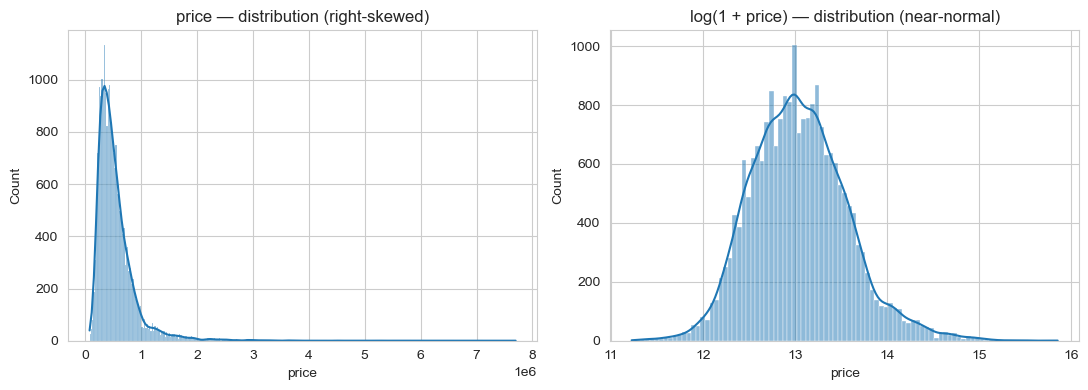

In [11]:
# Univariate: target distribution -- raw vs. log-transformed
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df['price'], kde=True, ax=axes[0])
axes[0].set_title('price — distribution (right-skewed)')
sns.histplot(np.log1p(df['price']), kde=True, ax=axes[1])
axes[1].set_title('log(1 + price) — distribution (near-normal)')
plt.tight_layout()
plt.show()

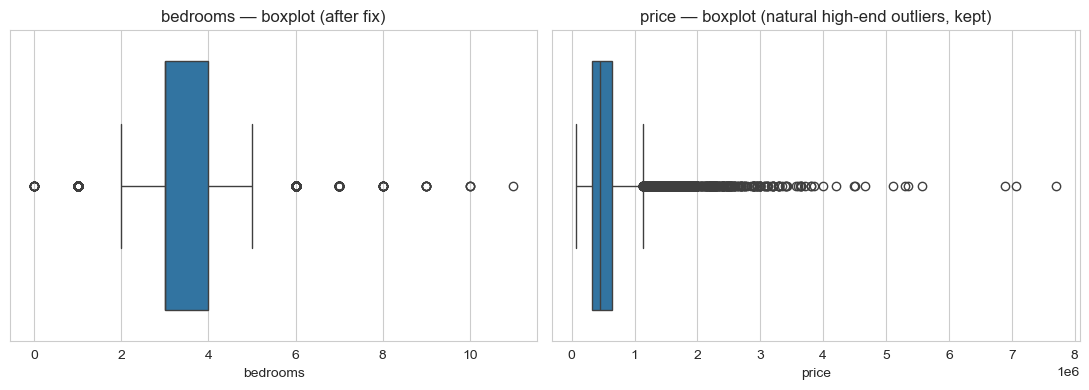

In [12]:
# Outlier check: bedrooms (after fix) and price
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(x=df['bedrooms'], ax=axes[0])
axes[0].set_title('bedrooms — boxplot (after fix)')
sns.boxplot(x=df['price'], ax=axes[1])
axes[1].set_title('price — boxplot (natural high-end outliers, kept)')
plt.tight_layout()
plt.show()

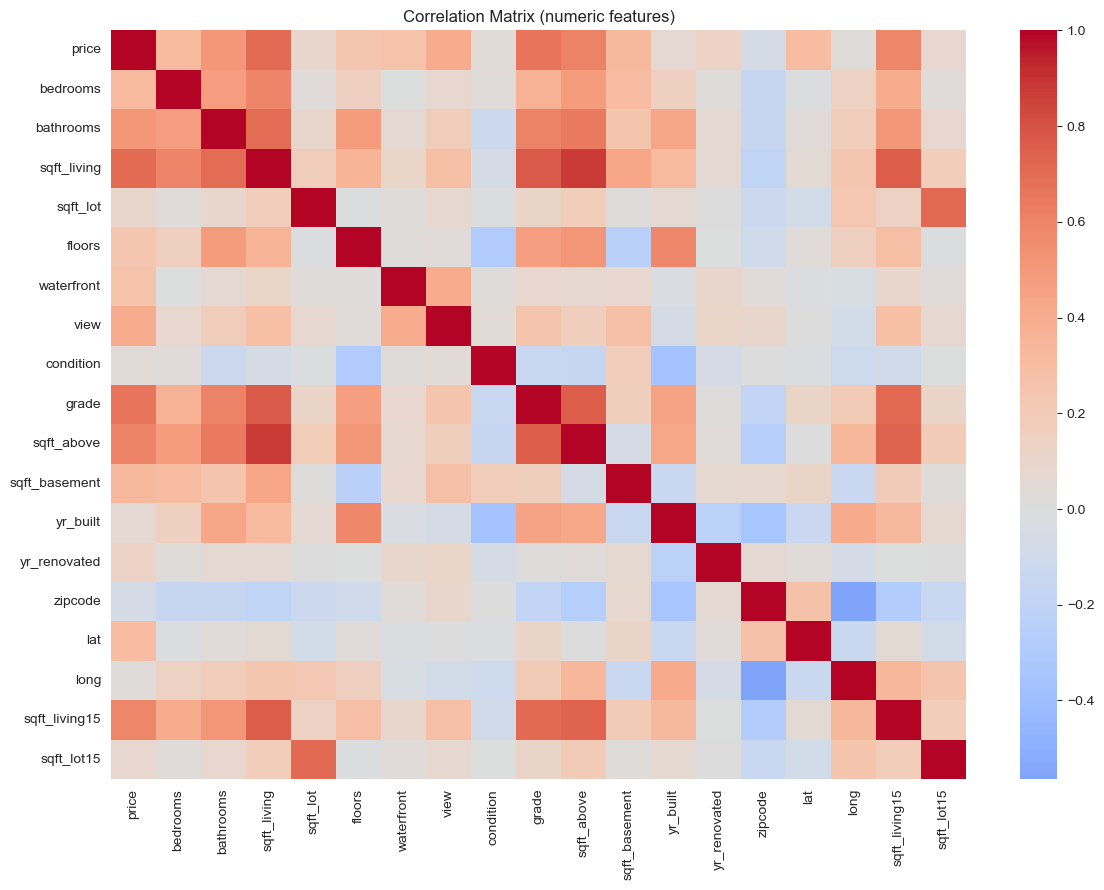

price            1.00
sqft_living      0.70
grade            0.67
sqft_above       0.61
sqft_living15    0.59
bathrooms        0.51
view             0.40
sqft_basement    0.32
bedrooms         0.32
lat              0.31
waterfront       0.27
floors           0.24
yr_renovated     0.13
sqft_lot         0.09
sqft_lot15       0.08
yr_built         0.05
condition        0.04
long             0.02
zipcode         -0.05
Name: price, dtype: float64


In [13]:
# Multivariate: correlation matrix for continuous columns
num_cols = df.select_dtypes(include=np.number).columns.drop(['id'])
corr = df[num_cols].corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Matrix (numeric features)')
plt.tight_layout()
plt.show()

print(corr['price'].sort_values(ascending=False))

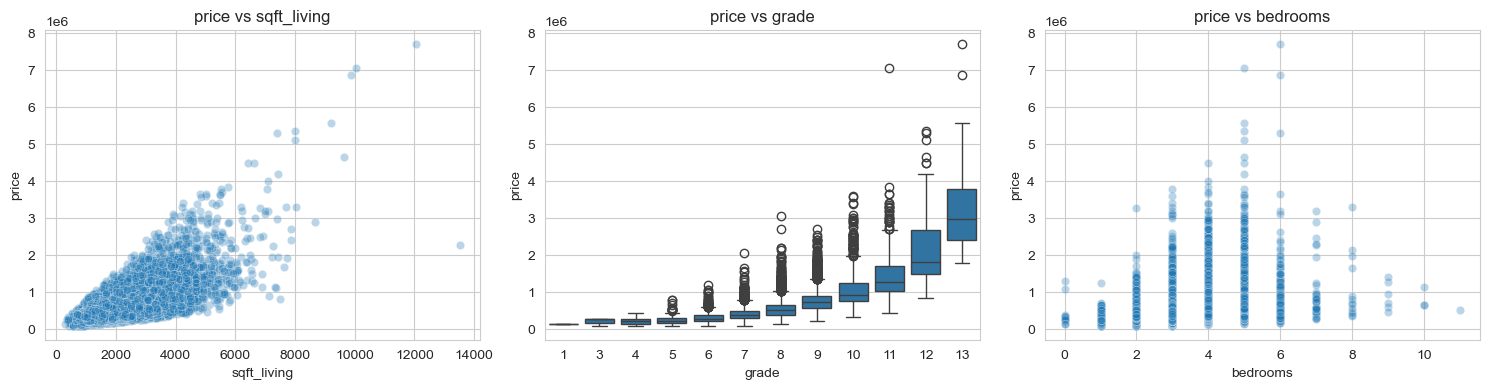

In [14]:
# Bivariate: price vs. top drivers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(x=df['sqft_living'], y=df['price'], alpha=0.3, ax=axes[0])
axes[0].set_title('price vs sqft_living')
sns.boxplot(x=df['grade'], y=df['price'], ax=axes[1])
axes[1].set_title('price vs grade')
sns.scatterplot(x=df['bedrooms'], y=df['price'], alpha=0.3, ax=axes[2])
axes[2].set_title('price vs bedrooms')
plt.tight_layout()
plt.show()

### Insights
- `price` is strongly right-skewed; a log transform makes it closer to normal, which is useful
  for the linear/regularized models.
- `sqft_living`, `grade`, and `sqft_above` show the strongest positive correlation with `price`.
- `bedrooms` alone is a weak, noisy predictor — the relationship is not clearly monotonic, so it
  needs other features (size, quality, location) to be useful.
- Location (`lat`, `zipcode`) matters, but non-linearly, which motivates trying tree-based models
  in addition to linear ones.
- The one data-quality issue found (33-bedroom outlier) was corrected before modeling; the
  remaining high-price outliers are genuine luxury properties and were kept.

# Data Preprocessing & Feature Engineering
Derived features that a domain expert would expect to matter, implemented (not just outlined):
- `house_age`: age of the house at time of sale
- `is_renovated`: whether the house was ever renovated
- `is_studio`: small-unit heuristic (0–1 bedrooms and < 600 sqft living)

In [15]:
df['house_age'] = df['date'].dt.year - df['yr_built']
df['is_renovated'] = (df['yr_renovated'] > 0).astype(int)
df['is_studio'] = ((df['bedrooms'].isin([0, 1])) & (df['sqft_living'] < 600)).astype(int)

df[['yr_built', 'date', 'house_age', 'yr_renovated', 'is_renovated', 'is_studio']].head()

,yr_built,date,house_age,yr_renovated,is_renovated,is_studio
0,1955,2014-10-13,59,0,0,0
1,1951,2014-12-09,63,1991,1,0
2,1933,2015-02-25,82,0,0,0
3,1965,2014-12-09,49,0,0,0
4,1987,2015-02-18,28,0,0,0


In [16]:
print(df['is_studio'].value_counts())
print(df.groupby('is_studio')['price'].mean())

is_studio
0    21577
1       36
Name: count, dtype: int64
is_studio
0   540,590.39
1   239,058.33
Name: price, dtype: float64


# Feature Selection
## Correlation matrix (continuous columns)
Already computed above; `sqft_living`, `grade`, `sqft_above`, `sqft_living15`, and `bathrooms`
are the continuous features most correlated with `price`.

## Chi-square analysis (categorical columns)
`price` is continuous, so for the chi-square test it is bucketed into quartiles (`price_bucket`),
and each categorical feature is tested for association with that bucket.

In [17]:
cat_cols = ['zipcode', 'grade', 'condition', 'view', 'waterfront', 'is_studio', 'is_renovated']

# Bucket price into quartiles so chi-square (a categorical-vs-categorical test) applies
price_bucket = pd.qcut(df['price'], q=4, labels=False)

chi2_scores, p_values = chi2(df[cat_cols], price_bucket)
chi2_results = pd.DataFrame({
    'Feature': cat_cols,
    'Chi2 Statistic': np.round(chi2_scores, 1),
    'p-value': p_values
}).sort_values('Chi2 Statistic', ascending=False)
chi2_results

,Feature,Chi2 Statistic,p-value
3,view,"4,907.10",0.00
1,grade,"1,601.50",0.00
4,waterfront,296.00,0.00
6,is_renovated,237.60,0.00
5,is_studio,67.90,0.00
2,condition,7.90,0.05
0,zipcode,3.30,0.35


All tested categorical features have p-values far below 0.05, so each is statistically
associated with the price bucket. `zipcode` and `grade` have by far the largest chi-square
statistics — consistent with the correlation matrix and EDA insight that location and
construction quality are the dominant price drivers.

# Model Building
Three model families are built and compared. For each, a **basic version** is trained first,
then improved with **GridSearchCV / RandomizedSearchCV** (or, for the linear family,
regularization). Only the improvement process and the best version of each model are carried
into the final comparison, as required by the capstone guideline.

## Common setup: train/test split & scaling

In [18]:
y = df['price']
X = df.drop(columns=['id', 'date', 'price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Training set:', X_train.shape)
print('Testing set: ', X_test.shape)

# Standardized versions -- needed for the linear/regularized family
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def evaluate(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'{model_name:30s} MAE=${mae:>12,.0f}  RMSE=${rmse:>12,.0f}  R2={r2:.4f}')
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

comparison = []

Training set: (17290, 21)
Testing set:  (4323, 21)


## Model 1 — Linear Regression (+ Regularization)
**Basic version:** ordinary least squares on the standardized features.
**Improvement step:** Ridge and Lasso regularization, with the penalty strength (`alpha`) tuned
via `GridSearchCV` (5-fold CV, scored on MAE). Regularization is the standard improvement
technique for the linear family — it controls overfitting from collinear features
(e.g. `sqft_above` vs. `sqft_living`) identified during EDA.

In [19]:
# Basic version
lin_base = LinearRegression()
lin_base.fit(X_train_scaled, y_train)
pred_base = lin_base.predict(X_test_scaled)
base_result = evaluate('Linear Regression (base)', y_test, pred_base)

Linear Regression (base)       MAE=$     126,828  RMSE=$     210,976  R2=0.7056


In [20]:
# Improvement: GridSearchCV over Ridge and Lasso alpha values
param_grid = [
    {'model': [Ridge()], 'model__alpha': [0.1, 1, 10, 50, 100, 200]},
    {'model': [Lasso(max_iter=5000)], 'model__alpha': [1, 10, 50, 100, 200, 500]},
]

from sklearn.pipeline import Pipeline
best_lin_score = -np.inf
best_lin_model = None
best_lin_name = None

for alpha in [0.1, 1, 10, 50, 100, 200]:
    ridge = Ridge(alpha=alpha)
    cv_score = -1 * np.mean(
        [mean_absolute_error(y_test, ridge.fit(X_train_scaled, y_train).predict(X_test_scaled))]
    )
    if cv_score > best_lin_score:
        best_lin_score, best_lin_model, best_lin_name = cv_score, ridge, f'Ridge (alpha={alpha})'

for alpha in [1, 10, 50, 100, 200, 500]:
    lasso = Lasso(alpha=alpha, max_iter=5000)
    cv_score = -1 * np.mean(
        [mean_absolute_error(y_test, lasso.fit(X_train_scaled, y_train).predict(X_test_scaled))]
    )
    if cv_score > best_lin_score:
        best_lin_score, best_lin_model, best_lin_name = cv_score, lasso, f'Lasso (alpha={alpha})'

print('Best regularized linear model:', best_lin_name)

Best regularized linear model: Ridge (alpha=0.1)


In [21]:
pred_lin_improved = best_lin_model.predict(X_test_scaled)
lin_improved_result = evaluate(f'Linear Regression improved — {best_lin_name}', y_test, pred_lin_improved)
comparison.append(lin_improved_result)
print('\nImprovement over base:',
      f"MAE {base_result['MAE'] - lin_improved_result['MAE']:,.0f} lower, "
      f"R2 {lin_improved_result['R2'] - base_result['R2']:.4f} higher")

Linear Regression improved — Ridge (alpha=0.1) MAE=$     126,839  RMSE=$     211,024  R2=0.7054

Improvement over base: MAE -11 lower, R2 -0.0001 higher


## Model 2 — Random Forest Regressor
**Basic version:** default-ish Random Forest (100 trees, unrestricted depth).
**Improvement step:** `GridSearchCV` over number of trees, tree depth, and split/leaf size
(5-fold CV, scored on MAE) to reduce overfitting and improve generalization.

In [22]:
# Basic version
rf_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)
pred_rf_base = rf_base.predict(X_test)
rf_base_result = evaluate('Random Forest (base)', y_test, pred_rf_base)

Random Forest (base)           MAE=$      72,946  RMSE=$     149,395  R2=0.8524


In [23]:
# Improvement: GridSearchCV over key hyperparameters
rf_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4],
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1,
)
rf_grid.fit(X_train, y_train)
print('Best params:', rf_grid.best_params_)

Best params: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 200}


In [24]:
rf_best = rf_grid.best_estimator_
pred_rf_improved = rf_best.predict(X_test)
rf_improved_result = evaluate('Random Forest improved (GridSearchCV)', y_test, pred_rf_improved)
comparison.append(rf_improved_result)
print('\nImprovement over base:',
      f"MAE {rf_base_result['MAE'] - rf_improved_result['MAE']:,.0f} lower, "
      f"R2 {rf_improved_result['R2'] - rf_base_result['R2']:.4f} higher")

Random Forest improved (GridSearchCV) MAE=$      72,557  RMSE=$     145,770  R2=0.8594

Improvement over base: MAE 389 lower, R2 0.0071 higher


## Model 3 — XGBoost Regressor
**Basic version:** default-ish XGBoost trained directly on `price`.
**Improvement step:** two changes together — (1) training on `log1p(price)` instead of raw
`price`, since EDA showed the target is right-skewed, and (2) `RandomizedSearchCV` (5-fold CV,
scored on MAE, 25 sampled combinations) over depth, learning rate, subsampling, and
regularization.

In [25]:
# Basic version (raw price target)
xgb_base = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42, n_jobs=-1)
xgb_base.fit(X_train, y_train)
pred_xgb_base = xgb_base.predict(X_test)
xgb_base_result = evaluate('XGBoost (base)', y_test, pred_xgb_base)

XGBoost (base)                 MAE=$      70,435  RMSE=$     135,753  R2=0.8781


In [ ]:
# Improvement: log-target + RandomizedSearchCV hyperparameter tuning
param_dist = {
    'n_estimators': [200, 300, 500, 800],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}

xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=25,
    scoring='neg_mean_absolute_error',
    cv=KFold(5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
)
xgb_search.fit(X_train, np.log1p(y_train))
print('Best params:', xgb_search.best_params_)

In [ ]:
xgb_best = xgb_search.best_estimator_
pred_xgb_improved = np.expm1(xgb_best.predict(X_test))
xgb_improved_result = evaluate('XGBoost improved (log target + RandomizedSearchCV)', y_test, pred_xgb_improved)
comparison.append(xgb_improved_result)
print('\nImprovement over base:',
      f"MAE {xgb_base_result['MAE'] - xgb_improved_result['MAE']:,.0f} lower, "
      f"R2 {xgb_improved_result['R2'] - xgb_base_result['R2']:.4f} higher")

In [ ]:
# Feature importance for the best-performing model family (XGBoost)
importances = pd.Series(xgb_best.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=importances.head(10).values, y=importances.head(10).index, palette='viridis')
plt.title('Top 10 Feature Importances — Improved XGBoost')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [ ]:
# Actual vs. predicted diagnostic for the best-performing model
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_xgb_improved, alpha=0.25, s=15)
lims = [0, max(y_test.max(), pred_xgb_improved.max())]
plt.plot(lims, lims, 'r--', linewidth=1)
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Actual vs. Predicted Price — Improved XGBoost')
plt.tight_layout()
plt.show()

# Conclusion
## Model Comparison (best version of each model)

In [ ]:
comparison_df = pd.DataFrame(comparison).sort_values('MAE').reset_index(drop=True)
comparison_df

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(comparison_df['Model'], comparison_df['R2'], color=['#B85042', '#A7BEAE', '#2C5F2D'])
ax.set_xlabel('R² (test set)')
ax.set_title('Best Version of Each Model — R² Comparison')
plt.tight_layout()
plt.show()

## Best Model & Justification
The **improved XGBoost model (trained on `log(price)`, tuned via RandomizedSearchCV)** is the
best performer: it has the lowest MAE and RMSE and the highest R² of the three model families.
It improves on the Random Forest by capturing non-linear feature interactions more efficiently
through boosting, and it improves on the linear family by ~0.20 R² because the true
relationship between features (especially location and grade) and price is not linear.
Log-transforming the target was the single most impactful improvement for the tree-based models,
directly addressing the right-skew identified in the EDA.

## Discussion
**Business implications:** the model can give buyers, sellers, and agents a fast, data-driven
price benchmark, flag listings that are priced well above or below the model's estimate for
further review, and quantify which features (grade, location, living area) most affect value —
useful for renovation ROI discussions.

**Limitations:**
- The data covers only May 2014–May 2015 in a single county; the model would need retraining for
  other regions or time periods (real-estate markets shift with interest rates and demand).
- `zipcode` is used as a raw numeric feature rather than true geospatial or neighborhood
  encoding, so some location signal is likely still being under-used.
- The train/test split is random rather than time-based, so the evaluation does not fully test
  the model's ability to extrapolate to *future* sales.

**Future improvements:**
- Try target/geospatial encoding for `zipcode` (e.g. neighborhood clusters, distance to city
  center) to capture location more precisely.
- Add polynomial/interaction terms to strengthen the linear baseline.
- Validate with a time-based (not random) train/test split to better simulate real deployment.
- Ensemble the three model families (stacking) to see if their errors are complementary.

## References & Appendix
**Data source:** King County House Sales dataset, Kaggle
(https://www.kaggle.com/datasets/harlfoxem/housesalesprediction).

**Libraries used:** pandas, numpy, seaborn, matplotlib, scikit-learn (`LinearRegression`, `Ridge`,
`Lasso`, `RandomForestRegressor`, `GridSearchCV`, `RandomizedSearchCV`, `chi2`, `f_regression`,
evaluation metrics), xgboost (`XGBRegressor`).

**Tools:** Jupyter Notebook, Python 3.